# IEMOCAP — Data Analysis & Preprocessing (Stage 0 of the MPLMM-extension project)

**Goal of this notebook:** load the pre-processed IEMOCAP pickles from Google Drive, understand them thoroughly (EDA), clean/normalize them, and produce a training-ready dataset with a **missing-modality simulator**, so that the MPLMM baseline reproduction and later components (2D spatial, RAG, Residual RAG, MoE-MMGM) can plug in directly.

| Section | What it does |
|---|---|
| 0 | Setup, paths, config |
| 1 | Load pickle, auto-detect structure, resolve keys, decode labels |
| 2 | EDA: overview, label balance, data quality, distributions, outliers, temporal, per-dimension, embeddings |
| 3 | Modality probes: unimodal strength, **reconstructability** of each modality, **retrieval (RAG) and residual-RAG feasibility** |
| 4 | Leakage / session checks, aligned vs unaligned comparison |
| 5 | Preprocessing (NaN fix, winsorize, padding-aware z-score) and save to Drive |
| 6 | PyTorch Dataset + **missing-modality simulator** + DataLoaders |

## 0. Setup

In [20]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running on Colab - skipping Drive mount")

import os, re, gc, json, pickle, hashlib, warnings, copy
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')

# ---------------- CONFIG (edit here) ----------------
IEMOCAP_DIR   = '/content/drive/MyDrive/IEMOCAP'
ALIGNED_PKL   = f'{IEMOCAP_DIR}/iemocap_data.pkl'
NOALIGN_PKL   = f'{IEMOCAP_DIR}/iemocap_data_noalign.pkl'
OUT_DIR       = f'{IEMOCAP_DIR}/processed'
EMOTION_NAMES = ['Neutral', 'Happy', 'Sad', 'Angry']   # confirm after label inspection (Section 1.4)
LOAD_NOALIGN  = True       # True => also inspect the 1.76 GB unaligned file (needs ~6+ GB free RAM)
SEED          = 42
MAX_TSNE      = 2000        # points used for t-SNE
# -----------------------------------------------------
np.random.seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')
MOD_COLORS = {'text': '#3A86FF', 'audio': '#FF006E', 'vision': '#8338EC'}
SPLIT_COLORS = {'train': '#2b5c8f', 'valid': '#e07a5f', 'test': '#81b29a'}
MODS, SPLITS = ['text', 'audio', 'vision'], ['train', 'valid', 'test']

for p in [ALIGNED_PKL, NOALIGN_PKL]:
    print(('OK  ' if os.path.exists(p) else 'MISSING  ') + p + (f'  ({os.path.getsize(p)/1e6:.1f} MB)' if os.path.exists(p) else ''))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK  /content/drive/MyDrive/IEMOCAP/iemocap_data.pkl  (291.7 MB)
OK  /content/drive/MyDrive/IEMOCAP/iemocap_data_noalign.pkl  (1891.9 MB)


## 1. Load pickle and detect structure

In [22]:
def load_pickle(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:          # py2-era pickles
            f.seek(0); return pickle.load(f, encoding='latin1')

def describe(obj, name='root', depth=0, max_depth=3):
    pad = '  ' * depth
    if isinstance(obj, dict):
        print(f"{pad}{name}: dict[{len(obj)}] keys={list(obj.keys())[:12]}")
        if depth < max_depth:
            for k, v in obj.items(): describe(v, str(k), depth + 1, max_depth)
    elif isinstance(obj, (list, tuple)):
        first = type(obj[0]).__name__ if len(obj) else '-'
        print(f"{pad}{name}: {type(obj).__name__}[{len(obj)}] first_elem={first}")
        if len(obj) and depth < max_depth: describe(obj[0], '[0]', depth + 1, max_depth)
    elif hasattr(obj, 'shape'):
        print(f"{pad}{name}: {type(obj).__name__} shape={tuple(obj.shape)} dtype={getattr(obj, 'dtype', '?')}")
    else:
        print(f"{pad}{name}: {type(obj).__name__} = {repr(obj)[:80]}")

print('Loading', NOALIGN_PKL)
RAW = load_pickle(NOALIGN_PKL)
print('Loaded.\n')
describe(RAW)

Loading /content/drive/MyDrive/IEMOCAP/iemocap_data_noalign.pkl
Loaded.

root: dict[3] keys=['test', 'train', 'valid']
  test: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(938, 4, 2) dtype=int64
    text: ndarray shape=(938, 20, 300) dtype=float64
    audio: ndarray shape=(938, 400, 74) dtype=float64
    vision: ndarray shape=(938, 500, 35) dtype=float64
  train: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(2717, 4, 2) dtype=int64
    text: ndarray shape=(2717, 20, 300) dtype=float64
    audio: ndarray shape=(2717, 400, 74) dtype=float64
    vision: ndarray shape=(2717, 500, 35) dtype=float64
  valid: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(798, 4, 2) dtype=int64
    text: ndarray shape=(798, 20, 300) dtype=float64
    audio: ndarray shape=(798, 400, 74) dtype=float64
    vision: ndarray shape=(798, 500, 35) dtype=float64


### 1.2 Resolve split / modality keys and convert to float32 arrays

In [23]:
SPLIT_ALIASES = {'train': ['train', 'training', 'tr'], 'valid': ['valid', 'val', 'validation', 'dev'], 'test': ['test', 'testing', 'te']}
KEY_ALIASES = {
    'text':   ['text', 'feature_T', 'text_mmsa', 'language', 'words'],
    'audio':  ['audio', 'feature_A', 'audio_mmsa', 'acoustic', 'covarep'],
    'vision': ['vision', 'feature_V', 'vision_mmsa', 'visual', 'facet', 'video'],
    'labels': ['labels', 'label', 'regression_labels', 'y'],
    'id':     ['id', 'ids', 'raw_text', 'sample_id', 'names'],
}
def first_key(d, aliases):
    return next((a for a in aliases if a in d), None)

def to_array(x):
    if hasattr(x, 'detach'): x = x.detach().cpu().numpy()
    if isinstance(x, np.ndarray) and x.dtype != object:
        arr = x.astype(np.float32, copy=False)
    else:                                     # list / object array of variable-length sequences -> zero pad
        seqs = [np.asarray(s, dtype=np.float32) for s in x]
        T = max(s.shape[0] for s in seqs); D = seqs[0].shape[-1]
        arr = np.zeros((len(seqs), T, D), np.float32)
        for i, s in enumerate(seqs): arr[i, :s.shape[0]] = s
    if arr.ndim == 2: arr = arr[:, None, :]   # (N, D) -> (N, 1, D)
    return arr

def build_data(raw):
    data = {}
    for split, aliases in SPLIT_ALIASES.items():
        sk = first_key(raw, aliases)
        if sk is None: raise KeyError(f"No '{split}' split found in top-level keys {list(raw.keys())}")
        d, entry = raw[sk], {}
        for name, al in KEY_ALIASES.items():
            k = first_key(d, al)
            if name in MODS:
                if k is None: raise KeyError(f"[{split}] modality '{name}' missing; keys={list(d.keys())}")
                entry[name] = to_array(d[k])
            elif name == 'labels':
                if k is None: raise KeyError(f"[{split}] labels missing; keys={list(d.keys())}")
                entry['labels_raw'] = np.asarray(d[k])
            else:
                entry['id'] = list(d[k]) if k is not None else None
        data[split] = entry
    return data

DATA = build_data(RAW)
del RAW; gc.collect()

rows = []
for s in SPLITS:
    e = DATA[s]
    rows.append({'split': s, 'N': len(e['text']), 'text': e['text'].shape[1:], 'audio': e['audio'].shape[1:],
                 'vision': e['vision'].shape[1:], 'labels_raw': e['labels_raw'].shape, 'label_dtype': e['labels_raw'].dtype,
                 'has_ids': e['id'] is not None, 'RAM_MB': round(sum(e[m].nbytes for m in MODS) / 1e6, 1)})
display(pd.DataFrame(rows))

,split,N,text,audio,vision,labels_raw,label_dtype,has_ids,RAM_MB
0,train,2717,"(20, 300)","(400, 74)","(500, 35)","(2717, 4, 2)",int64,False,577.1
1,valid,798,"(20, 300)","(400, 74)","(500, 35)","(798, 4, 2)",int64,False,169.5
2,test,938,"(20, 300)","(400, 74)","(500, 35)","(938, 4, 2)",int64,False,199.2


### 1.3 Decode labels (handles int / one-hot / multi-hot / sequence layouts)

In [24]:
def decode_labels(raw):
    # returns y (N,) int class [-1 = no class], Y (N,C) multi-hot or None, info str
    a = np.asarray(raw); notes = [f"raw shape {a.shape}, dtype {a.dtype}"]
    while a.ndim > 1 and a.shape[-1] == 1: a = a[..., 0]; notes.append('squeezed trailing singleton')
    if a.ndim == 3:
        if a.shape[-1] == 2: a = a.argmax(-1); notes.append('(N,C,2) -> argmax over last axis')
        else:                a = a.mean(1);    notes.append('(N,T,C) -> mean over time (CHECK THIS!)')
    if a.ndim == 1:
        if np.allclose(a, np.round(a)):
            y = a.astype(int); notes.append(f"1-D integer labels, unique={np.unique(y)}")
            return y, None, '; '.join(notes)
        notes.append('1-D CONTINUOUS labels -> regression target, binarised at 0 for y')
        return (a >= 0).astype(int), None, '; '.join(notes)
    C = a.shape[1]; binary = np.isin(a, [0, 1]).all(); rs = a.sum(1)
    if not binary:
        notes.append('2-D non-binary -> argmax (maybe regression/logits)'); return a.argmax(1), None, '; '.join(notes)
    if np.all(rs == 1):
        notes.append(f'one-hot over {C} classes -> argmax'); return a.argmax(1).astype(int), a.astype(int), '; '.join(notes)
    y = np.where(rs >= 1, a.argmax(1), -1).astype(int)
    kind = 'one-hot with some all-zero rows (no class => -1)' if rs.max() <= 1 else 'MULTI-LABEL (rows with >1 active); y = first active class'
    notes.append(f'{kind}, C={C}'); return y, a.astype(int), '; '.join(notes)

for s in SPLITS:
    y, Y, info = decode_labels(DATA[s]['labels_raw'])
    DATA[s]['y'], DATA[s]['Y'] = y, Y
    print(f"[{s:5}] {info}")

n_cls = int(max(DATA[s]['y'].max() for s in SPLITS)) + 1
CLASS_NAMES = EMOTION_NAMES if len(EMOTION_NAMES) == n_cls else [f'class_{i}' for i in range(n_cls)]
print('\nNumber of classes:', n_cls, '| names used:', CLASS_NAMES)
if n_cls != len(EMOTION_NAMES): print('>> EMOTION_NAMES length differs from detected classes - update the config cell.')

[train] raw shape (2717, 4, 2), dtype int64; (N,C,2) -> argmax over last axis; one-hot over 4 classes -> argmax
[valid] raw shape (798, 4, 2), dtype int64; (N,C,2) -> argmax over last axis; one-hot over 4 classes -> argmax
[test ] raw shape (938, 4, 2), dtype int64; (N,C,2) -> argmax over last axis; one-hot over 4 classes -> argmax

Number of classes: 4 | names used: ['Neutral', 'Happy', 'Sad', 'Angry']


### 1.4 Pooled (utterance-level) features — used by many analyses below

In [25]:
def pad_mask(X):                       # (N,T) True where timestep carries signal
    return np.abs(np.nan_to_num(X)).sum(-1) > 0

def pool(X):                           # mask-aware mean over time -> (N,D)
    X = np.nan_to_num(X); m = pad_mask(X)[..., None].astype(np.float32)
    return (X * m).sum(1) / np.maximum(m.sum(1), 1)

POOL = {s: {m: pool(DATA[s][m]) for m in MODS} for s in SPLITS}
print({m: POOL['train'][m].shape for m in MODS})

{'text': (2717, 300), 'audio': (2717, 74), 'vision': (2717, 35)}


## 2. Exploratory Data Analysis

### 2.1 Dataset overview and label balance

 LABEL DISTRIBUTION PER SPLIT


count            percent              
        train valid test   train  valid   test
Neutral   954   358  383   35.11  44.86  40.83
Happy     338   116  135   12.44  14.54  14.39
Sad       690   188  193   25.40  23.56  20.58
Angry     735   136  227   27.05  17.04  24.20

Chi-square test (class mix identical across splits?): chi2=53.06, dof=6, p=0.0000
Imbalance ratio (max/min class, train): 2.82
Inverse-frequency class weights (for weighted CE): {'Neutral': np.float32(0.712), 'Happy': np.float32(2.01), 'Sad': np.float32(0.984), 'Angry': np.float32(0.924)}


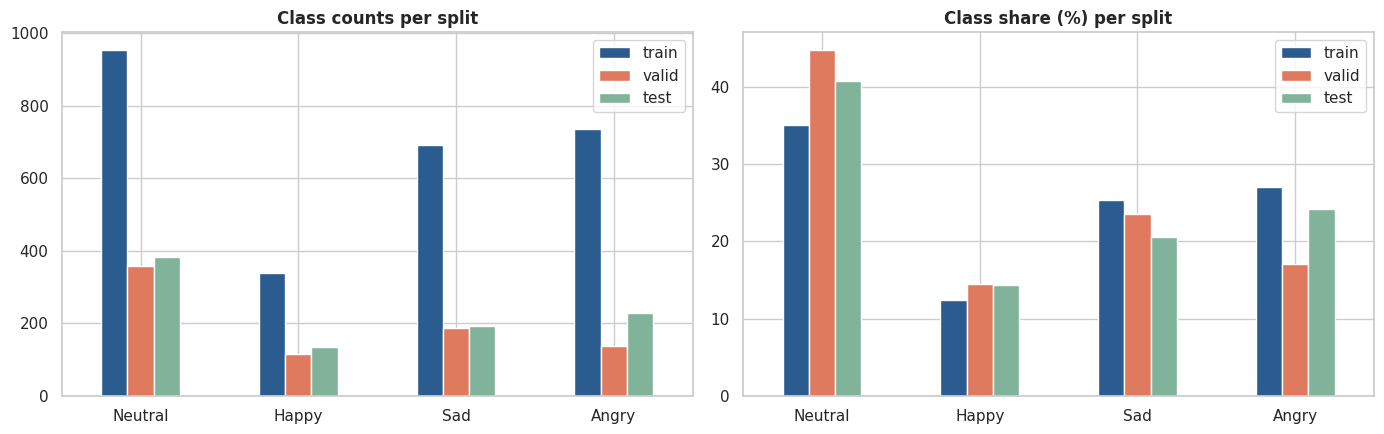

In [27]:
print('=' * 60, '\n LABEL DISTRIBUTION PER SPLIT\n', '=' * 60)
cnt = pd.DataFrame({s: pd.Series(DATA[s]['y']).value_counts().sort_index() for s in SPLITS}).fillna(0).astype(int)
cnt.index = [CLASS_NAMES[i] if i >= 0 else 'none(-1)' for i in cnt.index]
pct = (cnt / cnt.sum() * 100).round(2)
display(pd.concat({'count': cnt, 'percent': pct}, axis=1))

chi2, p, dof, _ = stats.chi2_contingency(cnt.values)
print(f"Chi-square test (class mix identical across splits?): chi2={chi2:.2f}, dof={dof}, p={p:.4f}")
tr = cnt['train'].values; print(f"Imbalance ratio (max/min class, train): {tr.max() / max(tr.min(), 1):.2f}")
valid_cls = [i for i in range(n_cls) if (DATA['train']['y'] == i).any()]
CLASS_WEIGHTS = np.array([len(DATA['train']['y'][DATA['train']['y'] >= 0]) / (n_cls * max((DATA['train']['y'] == i).sum(), 1)) for i in range(n_cls)], dtype=np.float32)
print('Inverse-frequency class weights (for weighted CE):', dict(zip(CLASS_NAMES, CLASS_WEIGHTS.round(3))))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
cnt.plot(kind='bar', ax=ax[0], color=[SPLIT_COLORS[s] for s in SPLITS]); ax[0].set_title('Class counts per split', fontweight='bold'); ax[0].tick_params(axis='x', rotation=0)
pct.plot(kind='bar', ax=ax[1], color=[SPLIT_COLORS[s] for s in SPLITS]); ax[1].set_title('Class share (%) per split', fontweight='bold'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

if DATA['train']['Y'] is not None and DATA['train']['Y'].sum(1).max() > 1:
    Y = DATA['train']['Y']; co = Y.T @ Y
    plt.figure(figsize=(5.5, 4.5)); sns.heatmap(co, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Label co-occurrence (train, multi-label)', fontweight='bold'); plt.show()

### 2.2 Data quality: NaN / Inf / padding / zero-signal / dead dimensions

In [28]:
rows = []
for s in SPLITS:
    for m in MODS:
        X = DATA[s][m]; zt = ~pad_mask(X)
        rows.append({'split': s, 'modality': m, 'shape': X.shape[1:], 'NaN': int(np.isnan(X).sum()), 'Inf': int(np.isinf(X).sum()),
                     'zero/pad timesteps %': round(zt.mean() * 100, 2), 'fully-zero samples': int(zt.all(1).sum()),
                     'min': float(np.nanmin(X)), 'max': float(np.nanmax(X)), '|x|>1e3 count': int((np.abs(np.nan_to_num(X)) > 1e3).sum())})
dq = pd.DataFrame(rows); display(dq)

print('\nDead / constant dimensions (train, over non-pad timesteps):')
for m in MODS:
    X = np.nan_to_num(DATA['train'][m]); flat = X[pad_mask(X)]
    sd = flat.std(0); dead = np.where(sd < 1e-8)[0]
    print(f"  {m:6}: {len(dead)} dead dims of {X.shape[-1]}" + (f"  -> idx {dead[:15].tolist()}" if len(dead) else ''))

# fully-zero samples matter for missing-modality work: they are *naturally* missing
fz = dq.pivot(index='modality', columns='split', values='fully-zero samples'); print('\nNaturally missing (fully-zero) samples:'); display(fz)

,split,modality,shape,NaN,Inf,zero/pad timesteps %,fully-zero samples,min,max,|x|>1e3 count
0,train,text,"(20, 300)",0,0,53.55,19,-4.209500,3.960900,0
1,train,audio,"(400, 74)",0,0,86.28,0,-50.069946,500.000000,0
2,train,vision,"(500, 35)",0,0,94.64,642,-26.645901,25.183901,0
3,valid,text,"(20, 300)",0,0,49.12,1,-3.936400,3.960900,0
4,valid,audio,"(400, 74)",0,0,85.66,0,-46.354736,500.000000,0
5,valid,vision,"(500, 35)",0,0,98.41,312,-23.094200,22.606300,0
6,test,text,"(20, 300)",0,0,57.43,24,-4.144500,3.960900,0
7,test,audio,"(400, 74)",0,0,85.76,0,-42.371689,500.000000,0
8,test,vision,"(500, 35)",0,0,96.82,221,-24.017401,28.459499,0



Dead / constant dimensions (train, over non-pad timesteps):
  text  : 0 dead dims of 300
  audio : 4 dead dims of 74  -> idx [36, 37, 38, 39]
  vision: 0 dead dims of 35

Naturally missing (fully-zero) samples:


split,test,train,valid
modality,,,
audio,0,0,0
text,24,19,1
vision,221,642,312


### 2.3 Feature value distributions and train→valid/test shift

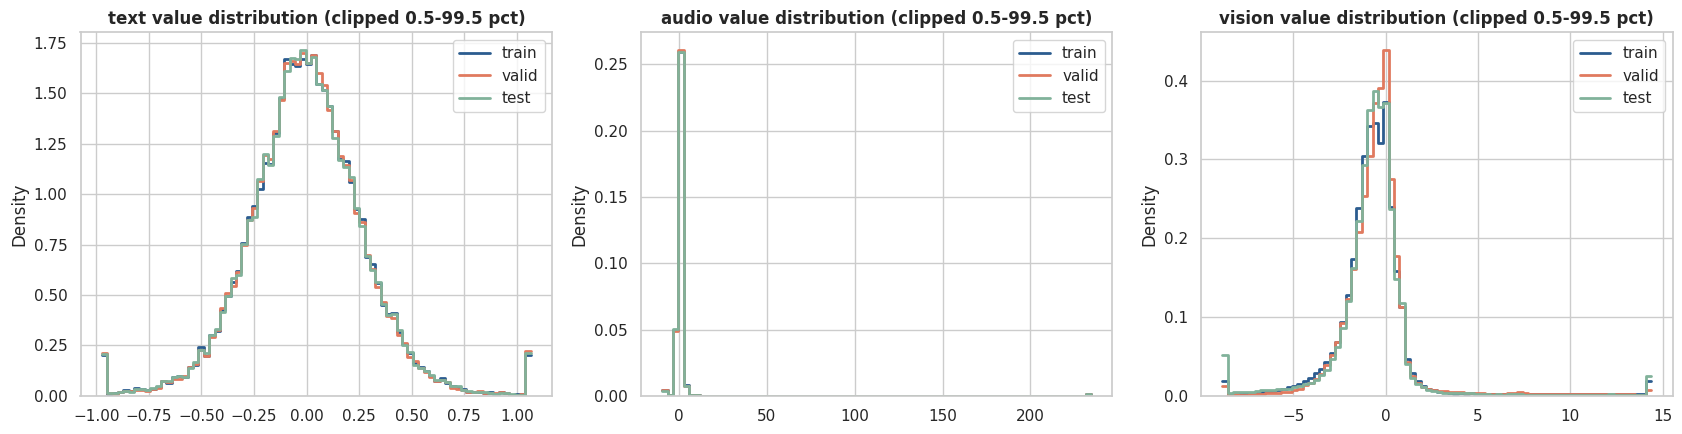

,modality,split,mean,std,skew,kurtosis,KS vs train
0,text,train,-0.0012,0.321100,0.8595,18.201000,0.0000
1,text,valid,-0.0017,0.322000,0.9179,18.173300,0.0044
2,text,test,-0.0020,0.321800,0.8070,17.402399,0.0033
3,audio,train,2.9266,27.162901,10.5969,123.049698,0.0000
4,audio,valid,2.7703,25.630301,11.1339,138.833496,0.0196
5,audio,test,2.6931,25.557301,10.9206,132.206894,0.0119
6,vision,train,-0.6061,2.575500,2.2686,17.280701,0.0000
7,vision,valid,-0.4751,2.248200,2.2660,17.111700,0.0630
8,vision,test,-0.7346,2.789800,1.2959,18.699200,0.0179


Interpretation: very different scales/kurtosis across modalities => per-modality normalization is mandatory; large KS vs train => distribution shift.


In [29]:
rng = np.random.default_rng(SEED)
def sample_vals(X, n=150_000):
    X = np.nan_to_num(X); v = X[pad_mask(X)].ravel()
    return rng.choice(v, size=min(n, len(v)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5)); rows = []
for ax, m in zip(axes, MODS):
    vals = {s: sample_vals(DATA[s][m]) for s in SPLITS}
    lo, hi = np.percentile(vals['train'], [0.5, 99.5])
    for s in SPLITS:
        sns.histplot(np.clip(vals[s], lo, hi), bins=80, stat='density', element='step', fill=False, color=SPLIT_COLORS[s], label=s, ax=ax, linewidth=2)
        ks = stats.ks_2samp(vals['train'], vals[s]).statistic if s != 'train' else 0.0
        rows.append({'modality': m, 'split': s, 'mean': vals[s].mean(), 'std': vals[s].std(), 'skew': stats.skew(vals[s]), 'kurtosis': stats.kurtosis(vals[s]), 'KS vs train': ks})
    ax.set_title(f'{m} value distribution (clipped 0.5-99.5 pct)', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).round(4))
print('Interpretation: very different scales/kurtosis across modalities => per-modality normalization is mandatory; large KS vs train => distribution shift.')

### 2.4 Sample-level norms and outliers (IQR)

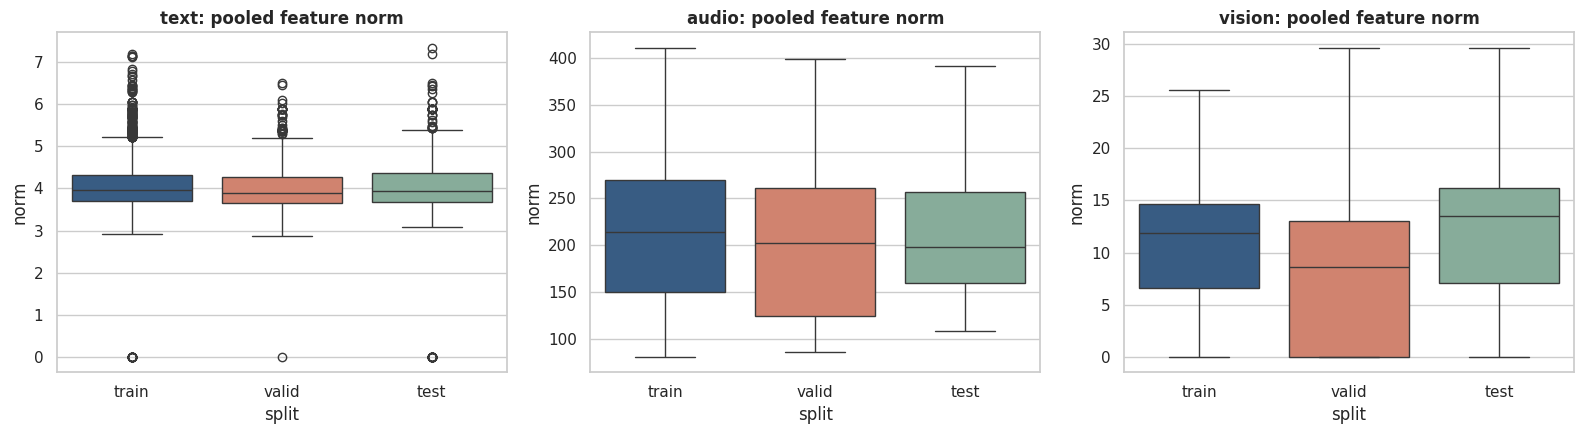

IQR outliers on TRAIN pooled-norms:
  text  :  216 outliers (7.95%)  bounds=[2.794, 5.225]
  audio :    0 outliers (0.00%)  bounds=[-29.353, 449.970]
  vision:    0 outliers (0.00%)  bounds=[-5.619, 26.881]


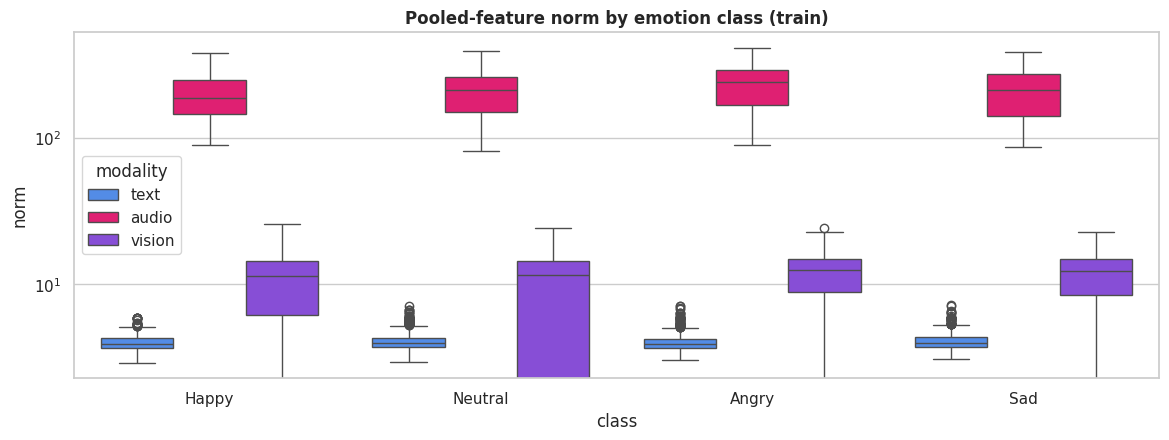

In [30]:
norm_rows = []
for s in SPLITS:
    for m in MODS:
        nr = np.linalg.norm(POOL[s][m], axis=1)
        norm_rows += [{'split': s, 'modality': m, 'norm': v, 'class': (CLASS_NAMES[c] if c >= 0 else 'none')} for v, c in zip(nr, DATA[s]['y'])]
ndf = pd.DataFrame(norm_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m in zip(axes, MODS):
    sns.boxplot(data=ndf[ndf.modality == m], x='split', y='norm', order=SPLITS, palette=SPLIT_COLORS, ax=ax)
    ax.set_title(f'{m}: pooled feature norm', fontweight='bold');
    if ndf[ndf.modality == m].norm.max() / max(ndf[ndf.modality == m].norm.median(), 1e-9) > 20: ax.set_yscale('log')
plt.tight_layout(); plt.show()

print('IQR outliers on TRAIN pooled-norms:')
OUTLIER_MASK = {}
for m in MODS:
    v = ndf[(ndf.split == 'train') & (ndf.modality == m)].norm.values
    q1, q3 = np.percentile(v, [25, 75]); iqr = q3 - q1; ok = (v >= q1 - 1.5 * iqr) & (v <= q3 + 1.5 * iqr)
    OUTLIER_MASK[m] = ~ok; print(f"  {m:6}: {(~ok).sum():4d} outliers ({(~ok).mean() * 100:.2f}%)  bounds=[{q1 - 1.5 * iqr:.3f}, {q3 + 1.5 * iqr:.3f}]")

plt.figure(figsize=(14, 4.5)); sns.boxplot(data=ndf[ndf.split == 'train'], x='class', y='norm', hue='modality', palette=MOD_COLORS)
plt.yscale('log'); plt.title('Pooled-feature norm by emotion class (train)', fontweight='bold'); plt.show()

### 2.5 Temporal structure (aligned sequences)

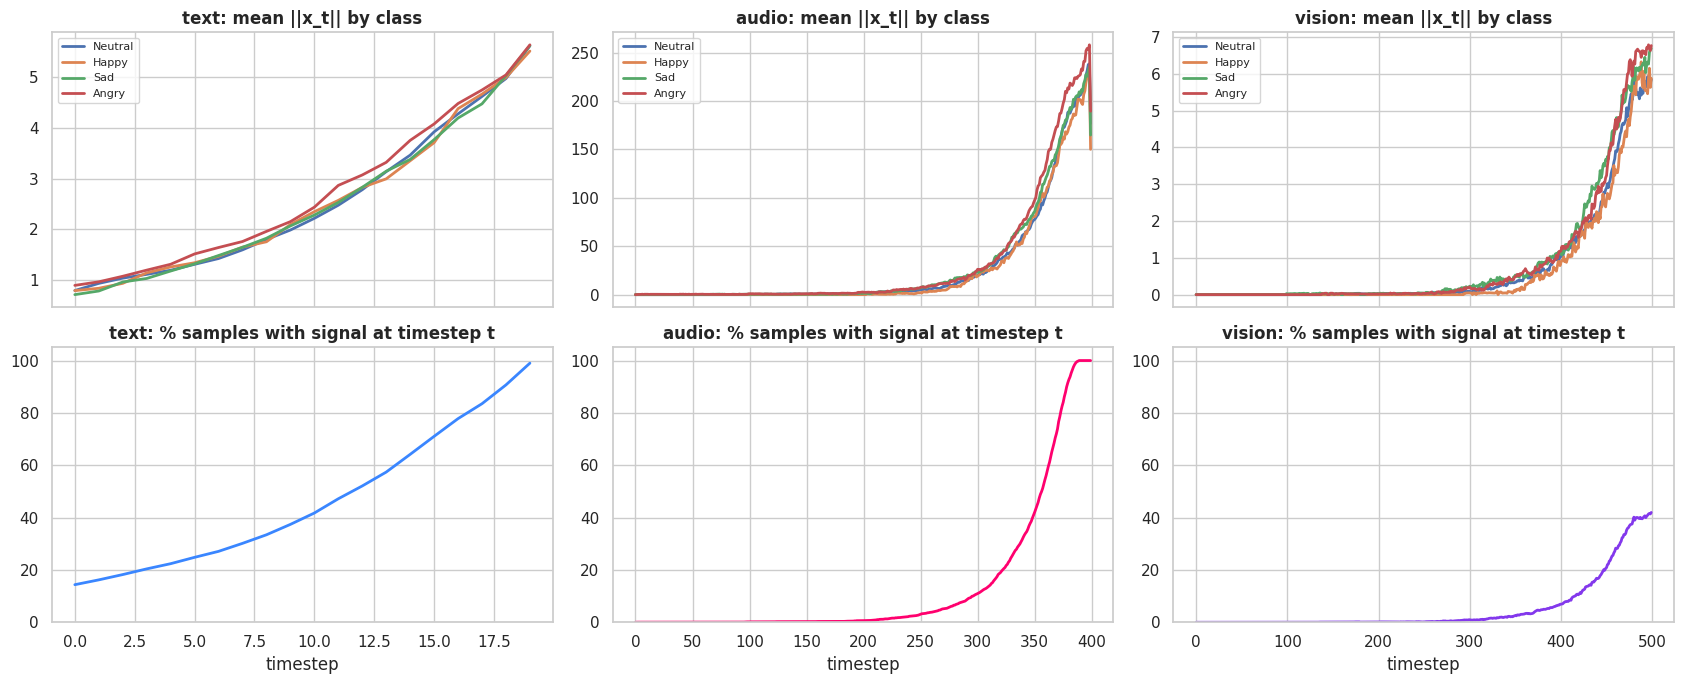

Effective (non-pad) sequence length per modality (train):


,count,mean,std,min,25%,50%,75%,max
text,2717.0,9.29,6.20,0.0,4.0,8.0,14.0,20.0
audio,2717.0,54.87,37.71,11.0,29.0,43.0,70.0,399.0
vision,2717.0,26.79,35.19,0.0,1.0,15.0,40.0,381.0


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(17, 7), sharex='col')
for j, m in enumerate(MODS):
    X = np.nan_to_num(DATA['train'][m]); y = DATA['train']['y']; nt = np.linalg.norm(X, axis=-1)  # (N,T)
    for c in range(n_cls):
        if (y == c).any(): axes[0, j].plot(nt[y == c].mean(0), label=CLASS_NAMES[c], linewidth=2)
    axes[0, j].set_title(f'{m}: mean ||x_t|| by class', fontweight='bold'); axes[0, j].legend(fontsize=8)
    axes[1, j].plot(pad_mask(X).mean(0) * 100, color=MOD_COLORS[m], linewidth=2); axes[1, j].set_ylim(0, 105)
    axes[1, j].set_title(f'{m}: % samples with signal at timestep t', fontweight='bold'); axes[1, j].set_xlabel('timestep')
plt.tight_layout(); plt.show()
eff = {m: pad_mask(DATA['train'][m]).sum(1) for m in MODS}
print('Effective (non-pad) sequence length per modality (train):')
display(pd.DataFrame({m: pd.Series(v).describe() for m, v in eff.items()}).T.round(2))

### 2.6 Per-dimension analysis: scale, discriminative power, class profiles

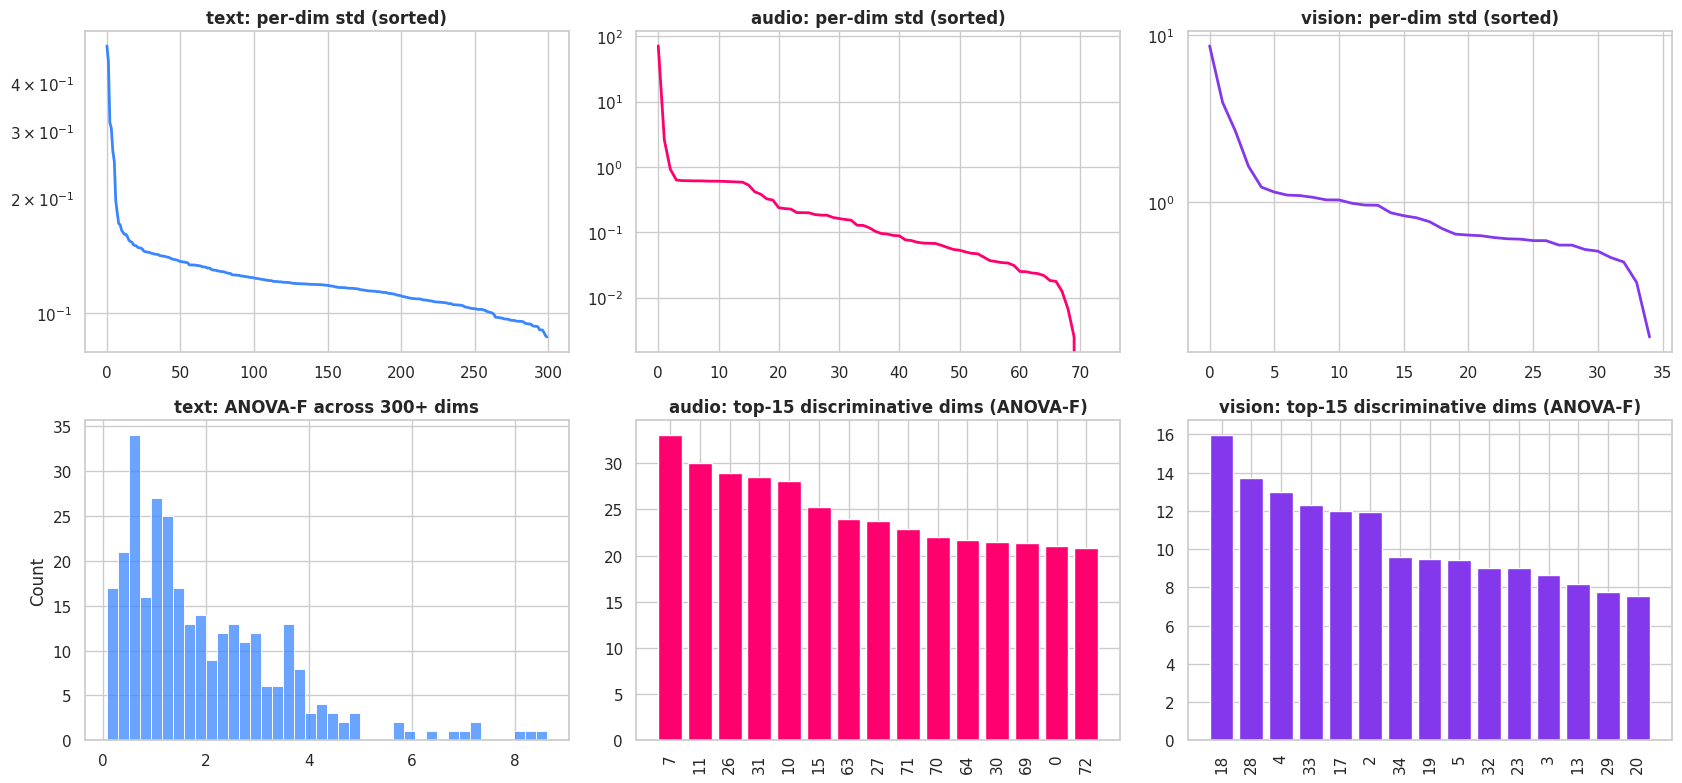

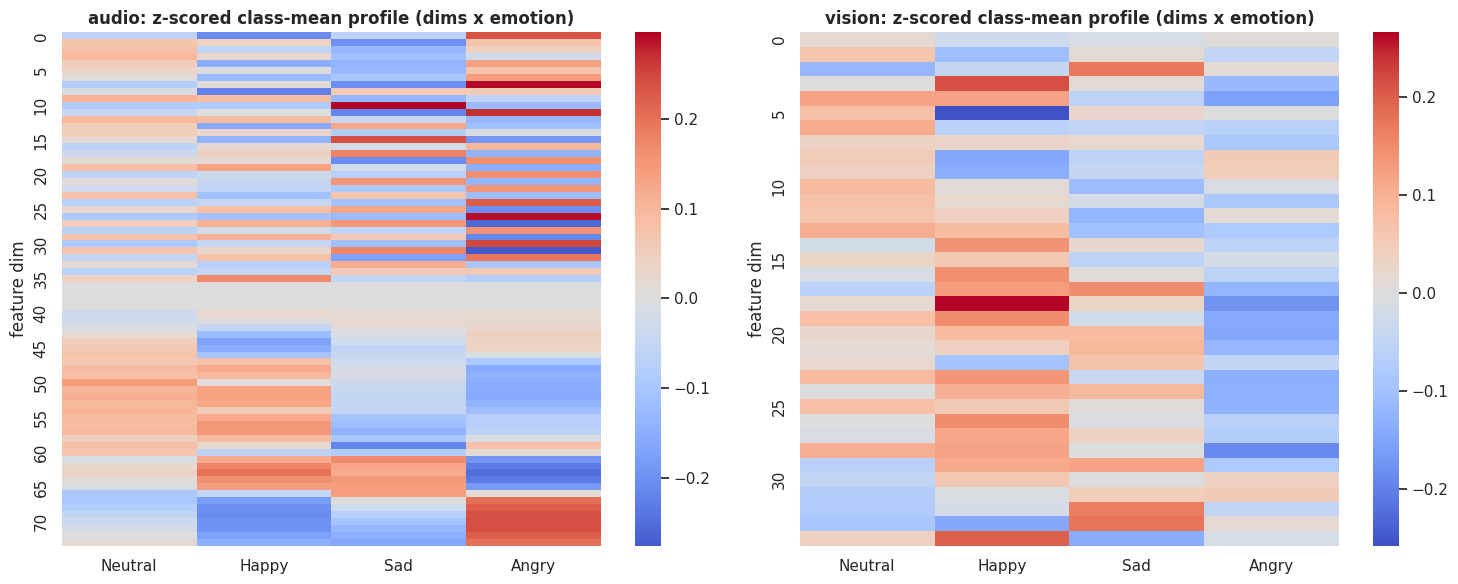

In [32]:
from sklearn.feature_selection import f_classif
ytr = DATA['train']['y']; keep = ytr >= 0
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for j, m in enumerate(MODS):
    P = POOL['train'][m][keep]; sd = P.std(0)
    axes[0, j].plot(np.sort(sd)[::-1], color=MOD_COLORS[m], linewidth=2); axes[0, j].set_yscale('log')
    axes[0, j].set_title(f'{m}: per-dim std (sorted)', fontweight='bold')
    F, _ = f_classif(P, ytr[keep]); F = np.nan_to_num(F)
    if m == 'text': sns.histplot(F, bins=40, color=MOD_COLORS[m], ax=axes[1, j]); axes[1, j].set_title('text: ANOVA-F across 300+ dims', fontweight='bold')
    else:
        top = np.argsort(F)[::-1][:15]; axes[1, j].bar(range(15), F[top], color=MOD_COLORS[m]); axes[1, j].set_xticks(range(15)); axes[1, j].set_xticklabels(top, rotation=90)
        axes[1, j].set_title(f'{m}: top-15 discriminative dims (ANOVA-F)', fontweight='bold')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, m in zip(axes, ['audio', 'vision']):
    P = POOL['train'][m][keep]; Z = (P - P.mean(0)) / (P.std(0) + 1e-8)
    prof = np.stack([Z[ytr[keep] == c].mean(0) for c in range(n_cls) if (ytr[keep] == c).any()])
    sns.heatmap(prof.T, cmap='coolwarm', center=0, ax=ax, yticklabels=5, xticklabels=[CLASS_NAMES[c] for c in range(n_cls) if (ytr[keep] == c).any()])
    ax.set_title(f'{m}: z-scored class-mean profile (dims x emotion)', fontweight='bold'); ax.set_ylabel('feature dim')
plt.tight_layout(); plt.show()

### 2.7 Low-dimensional structure: PCA variance, t-SNE, cluster separability

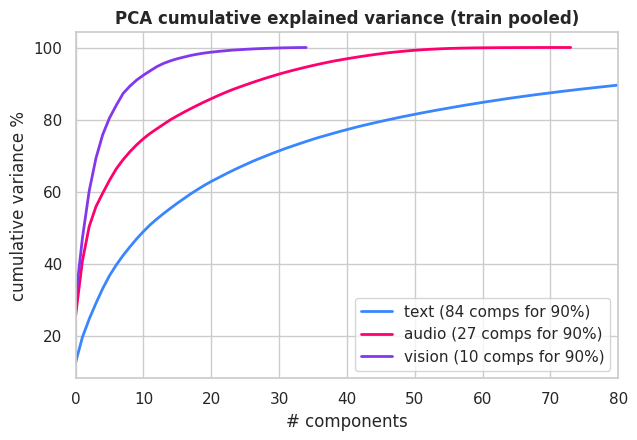

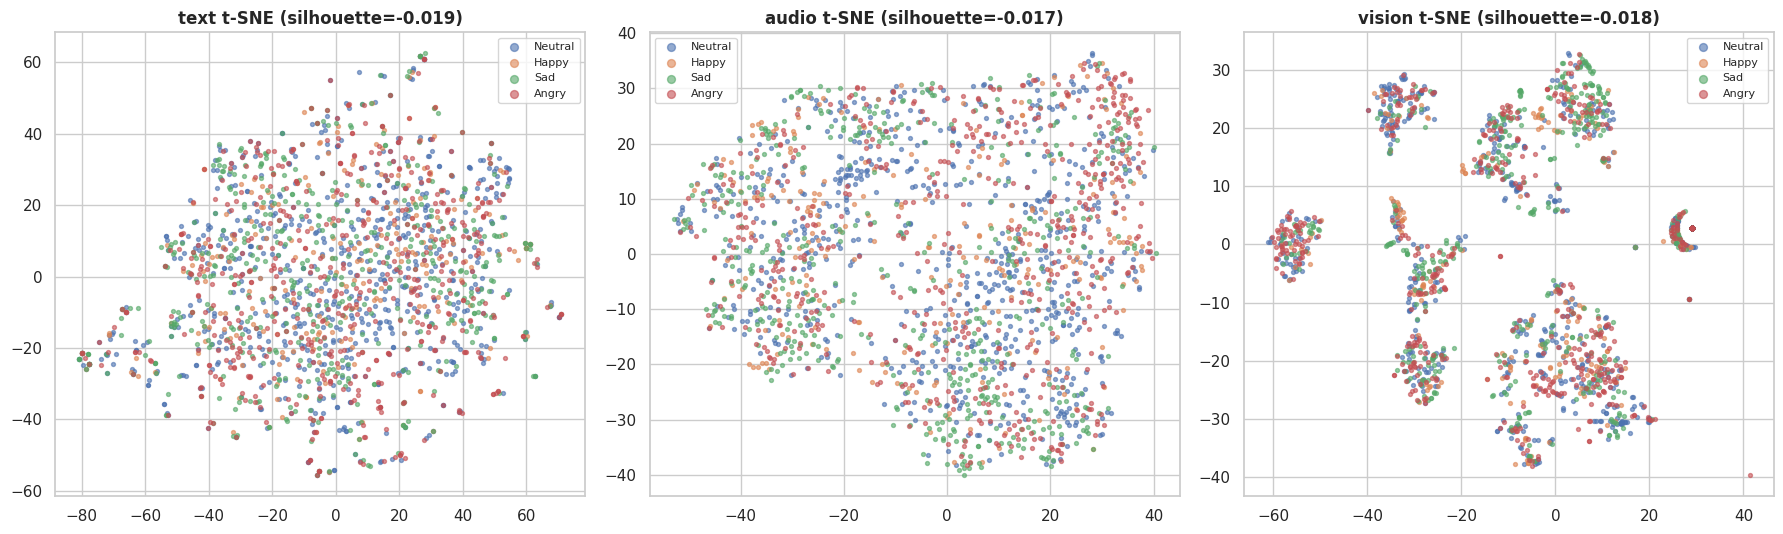

Silhouette by modality (higher => emotions cluster better in that modality): {'text': np.float32(-0.019), 'audio': np.float32(-0.017), 'vision': np.float32(-0.018)}


In [33]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

fig, ax = plt.subplots(figsize=(7, 4.5)); sil = {}
for m in MODS:
    Z = StandardScaler().fit_transform(POOL['train'][m]); pca = PCA().fit(Z)
    ax.plot(np.cumsum(pca.explained_variance_ratio_) * 100, label=f"{m} ({(np.cumsum(pca.explained_variance_ratio_) < .9).sum() + 1} comps for 90%)", color=MOD_COLORS[m], linewidth=2)
ax.set_xlabel('# components'); ax.set_ylabel('cumulative variance %'); ax.set_xlim(0, 80); ax.legend(); ax.set_title('PCA cumulative explained variance (train pooled)', fontweight='bold'); plt.show()

idx = np.random.default_rng(SEED).choice(len(ytr), size=min(MAX_TSNE, len(ytr)), replace=False); idx = idx[ytr[idx] >= 0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, m in zip(axes, MODS):
    Z = StandardScaler().fit_transform(POOL['train'][m])[idx]; Z = PCA(n_components=min(30, Z.shape[1])).fit_transform(Z)
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(Z)
    sil[m] = silhouette_score(Z, ytr[idx]);
    for c in range(n_cls): ax.scatter(*E[ytr[idx] == c].T, s=8, alpha=.6, label=CLASS_NAMES[c])
    ax.set_title(f'{m} t-SNE (silhouette={sil[m]:.3f})', fontweight='bold'); ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()
print('Silhouette by modality (higher => emotions cluster better in that modality):', {k: round(v, 3) for k, v in sil.items()})

## 3. Modality probes (motivate the missing-modality study)

### 3.1 Unimodal / bimodal / trimodal linear probe — which modality matters most?

,available modalities,Acc,Macro-F1,Weighted-F1
4,text+vision,0.3262,0.3039,0.3340
2,vision,0.3486,0.3007,0.3440
3,text+audio,0.3124,0.2994,0.3150
0,text,0.3060,0.2950,0.3130
1,audio,0.3049,0.2893,0.2911
5,audio+vision,0.2814,0.2674,0.2702
6,text+audio+vision,0.2793,0.2650,0.2801


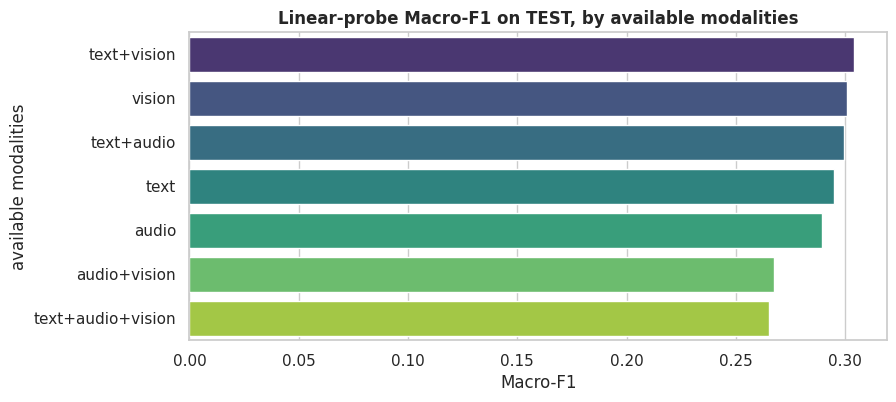

This is a *rough* floor (mean-pooled + logistic regression). The real MulT/MPLMM numbers come in the baseline stage.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from itertools import combinations

def feats(split, mods): return np.concatenate([POOL[split][m] for m in mods], axis=1)
def probe(mods):
    tr, te = DATA['train']['y'] >= 0, DATA['test']['y'] >= 0
    sc = StandardScaler().fit(feats('train', mods)[tr])
    clf = LogisticRegression(max_iter=1000, C=0.05, class_weight='balanced').fit(sc.transform(feats('train', mods)[tr]), DATA['train']['y'][tr])
    p = clf.predict(sc.transform(feats('test', mods)[te])); yt = DATA['test']['y'][te]
    return accuracy_score(yt, p), f1_score(yt, p, average='macro'), f1_score(yt, p, average='weighted')

combos = [c for r in (1, 2, 3) for c in combinations(MODS, r)]
res = [{'available modalities': '+'.join(c), 'Acc': a, 'Macro-F1': f, 'Weighted-F1': w} for c in combos for a, f, w in [probe(list(c))]]
probe_df = pd.DataFrame(res).sort_values('Macro-F1', ascending=False).round(4); display(probe_df)
plt.figure(figsize=(9, 4)); sns.barplot(data=probe_df, y='available modalities', x='Macro-F1', palette='viridis'); plt.title('Linear-probe Macro-F1 on TEST, by available modalities', fontweight='bold'); plt.show()
print('This is a *rough* floor (mean-pooled + logistic regression). The real MulT/MPLMM numbers come in the baseline stage.')

### 3.2 Reconstructability: how well can a missing modality be predicted from the others?
Proxy for the MMGM task on pooled features (Ridge regression, R² on test; 0 = predicting the train mean).

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

SC = {m: StandardScaler().fit(POOL['train'][m]) for m in MODS}
ZP = {s: {m: np.nan_to_num(SC[m].transform(POOL[s][m])) for m in MODS} for s in SPLITS}
def cat(s, mods): return np.concatenate([ZP[s][m] for m in mods], axis=1)

RECON = {}
for miss in MODS:
    avail = [m for m in MODS if m != miss]
    rg = Ridge(alpha=100.0).fit(cat('train', avail), ZP['train'][miss])
    pred = rg.predict(cat('test', avail)); RECON[miss] = r2_score(ZP['test'][miss], pred)
    # per-source contribution
    for a in avail:
        r = Ridge(alpha=100.0).fit(ZP['train'][a], ZP['train'][miss]); RECON[(miss, a)] = r2_score(ZP['test'][miss], r.predict(ZP['test'][a]))
rec_df = pd.DataFrame([{'missing': m, 'from': '+'.join([a for a in MODS if a != m]), 'R2 (test)': RECON[m]} for m in MODS] +
                      [{'missing': k[0], 'from': k[1], 'R2 (test)': v} for k, v in RECON.items() if isinstance(k, tuple)]).round(4)
display(rec_df.sort_values(['missing', 'R2 (test)'], ascending=[True, False]))
print('Low R2 => a plain linear map cannot reconstruct that modality => room for RAG / MoE to help.')

,missing,from,R2 (test)
5,audio,text,-0.1698
6,audio,vision,-0.1746
1,audio,text+vision,-0.2200
3,text,audio,-0.0021
4,text,vision,-0.0168
0,text,audio+vision,-0.0194
7,vision,text,-0.1130
8,vision,audio,-0.4177
2,vision,text+audio,-0.5020


Low R2 => a plain linear map cannot reconstruct that modality => room for RAG / MoE to help.


### 3.3 RAG & Residual-RAG feasibility (kNN retrieval on pooled features)
* **RAG probe:** query = available modalities → retrieve top-K *complete* train samples → average their missing-modality vector → R² on test.
* **Residual-RAG probe:** use Ridge as base generator; retrieve neighbours' **out-of-fold residuals** and add λ·mean-residual. If R² improves, residuals are spatially correlated (the locality assumption holds).

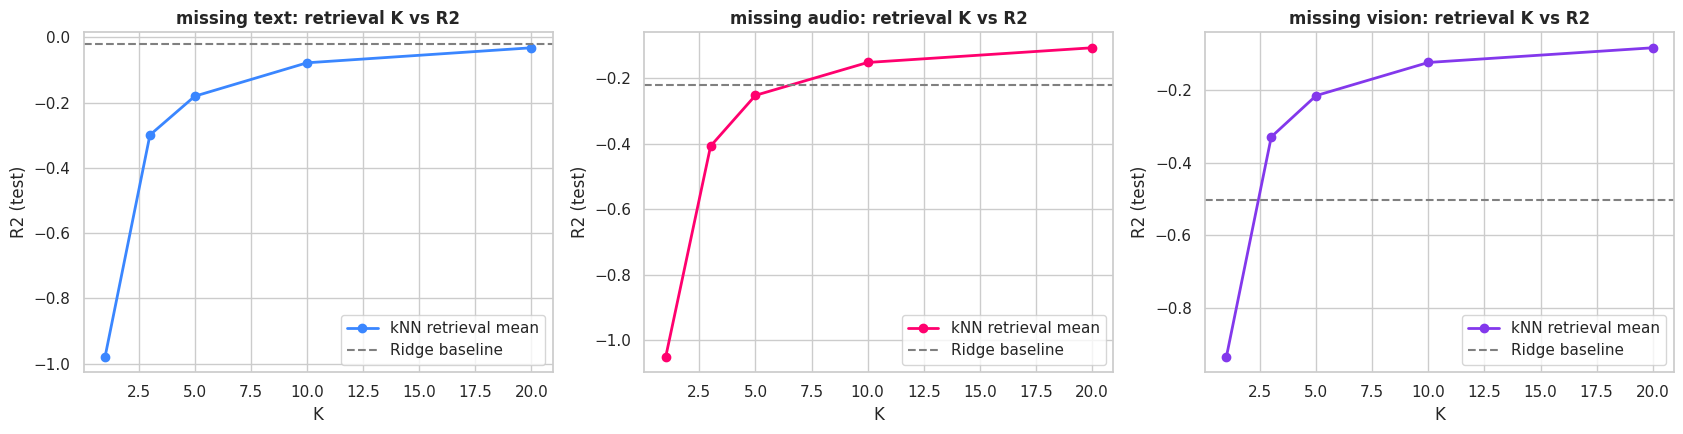

Residual-RAG probe (R2 on test; lambda=0 is the plain Ridge baseline):


lambda        0.00    0.25    0.50    1.00
missing K                                 
audio   1  -0.2200 -0.2627 -0.4537 -1.2807
        3  -0.2200 -0.2286 -0.2894 -0.5677
        5  -0.2200 -0.2197 -0.2512 -0.4093
        10 -0.2200 -0.2186 -0.2328 -0.3080
        20 -0.2200 -0.2207 -0.2288 -0.2674
text    1  -0.0194 -0.0776 -0.2651 -1.0275
        3  -0.0194 -0.0358 -0.0933 -0.3317
        5  -0.0194 -0.0297 -0.0647 -0.2086
        10 -0.0194 -0.0233 -0.0393 -0.1077
        20 -0.0194 -0.0212 -0.0289 -0.0621
vision  1  -0.5020 -0.5501 -0.6999 -1.3043
        3  -0.5020 -0.5178 -0.5650 -0.7534
        5  -0.5020 -0.5131 -0.5423 -0.6548
        10 -0.5020 -0.5064 -0.5197 -0.5726
        20 -0.5020 -0.5041 -0.5104 -0.5356

,missing,K,lambda,R2,gain over baseline
33,audio,10,0.25,-0.2186,0.0014
0,text,1,0.00,-0.0194,0.0000
40,vision,1,0.00,-0.5020,0.0000


If gain over baseline is ~0 or negative for a modality, Residual RAG is unlikely to help there (matches the proposal: keep only if supported).


In [36]:
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import cross_val_predict, KFold

Ks, LAMS = [1, 3, 5, 10, 20], [0.0, 0.25, 0.5, 1.0]
rag_rows, res_rows = [], []
for miss in MODS:
    avail = [m for m in MODS if m != miss]
    Xtr, Xte = cat('train', avail), cat('test', avail); Ytr, Yte = ZP['train'][miss], ZP['test'][miss]
    pca = PCA(n_components=min(32, Xtr.shape[1]), random_state=SEED).fit(Xtr)
    q = lambda X: (lambda Z: Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-8))(pca.transform(X))
    nn_ = NearestNeighbors(n_neighbors=max(Ks), metric='euclidean').fit(q(Xtr)); _, nb = nn_.kneighbors(q(Xte))
    base = Ridge(alpha=100.0).fit(Xtr, Ytr); p0 = base.predict(Xte)
    oof = cross_val_predict(Ridge(alpha=100.0), Xtr, Ytr, cv=KFold(5, shuffle=True, random_state=SEED)); R_tr = Ytr - oof
    rag_rows.append({'missing': miss, 'method': 'Ridge (no retrieval)', 'K': 0, 'R2': r2_score(Yte, p0)})
    for K in Ks:
        rag_rows.append({'missing': miss, 'method': 'kNN retrieval mean', 'K': K, 'R2': r2_score(Yte, Ytr[nb[:, :K]].mean(1))})
        for lam in LAMS: res_rows.append({'missing': miss, 'K': K, 'lambda': lam, 'R2': r2_score(Yte, p0 + lam * R_tr[nb[:, :K]].mean(1))})
rag_df, res_df = pd.DataFrame(rag_rows), pd.DataFrame(res_rows)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, miss in zip(axes, MODS):
    d = rag_df[(rag_df.missing == miss) & (rag_df.K > 0)]; ax.plot(d.K, d.R2, 'o-', linewidth=2, color=MOD_COLORS[miss], label='kNN retrieval mean')
    ax.axhline(rag_df[(rag_df.missing == miss) & (rag_df.K == 0)].R2.iloc[0], color='gray', linestyle='--', label='Ridge baseline')
    ax.set_title(f'missing {miss}: retrieval K vs R2', fontweight='bold'); ax.set_xlabel('K'); ax.set_ylabel('R2 (test)'); ax.legend()
plt.tight_layout(); plt.show()

print('Residual-RAG probe (R2 on test; lambda=0 is the plain Ridge baseline):')
display(res_df.pivot_table(index=['missing', 'K'], columns='lambda', values='R2').round(4))
best = res_df.loc[res_df.groupby('missing').R2.idxmax()]; base0 = res_df[res_df['lambda'] == 0].groupby('missing').R2.first()
best['gain over baseline'] = best.apply(lambda r: r.R2 - base0[r.missing], axis=1); display(best.round(4))
print('If gain over baseline is ~0 or negative for a modality, Residual RAG is unlikely to help there (matches the proposal: keep only if supported).')

## 4. Leakage, sessions and aligned-vs-unaligned

In [37]:
# 4.1 duplicate samples across splits (hash of text+audio arrays)
def h(i, s): return hashlib.md5(DATA[s]['text'][i].tobytes() + DATA[s]['audio'][i].tobytes()).hexdigest()
H = {s: [h(i, s) for i in range(len(DATA[s]['text']))] for s in SPLITS}
for s in SPLITS: print(f"{s}: {len(H[s]) - len(set(H[s]))} within-split duplicate samples")
for a, b in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]: print(f"overlap {a} vs {b}: {len(set(H[a]) & set(H[b]))} identical samples")

# 4.2 session / speaker analysis (IEMOCAP ids look like Ses01F_impro01_F000)
ids = DATA['train']['id']
if ids is not None and isinstance(ids[0], (str, bytes)):
    dec = lambda x: x.decode() if isinstance(x, bytes) else str(x)
    pat = re.compile(r'Ses(\d\d)([FM])')
    rows = []
    for s in SPLITS:
        for i in DATA[s]['id']:
            mt = pat.search(dec(i)); rows.append({'split': s, 'session': mt.group(1) if mt else '?', 'gender': mt.group(2) if mt else '?'})
    sdf = pd.DataFrame(rows); print('\nSession x split:'); display(pd.crosstab(sdf.session, sdf.split))
    print('Sessions shared across splits => speaker leakage unless the split is session-based.')
else:
    print('\nNo string IDs in the pickle -> cannot verify session/speaker separation. (Standard MulT-style splits: sessions 1-4 train/valid, session 5 test.)')

train: 0 within-split duplicate samples
valid: 0 within-split duplicate samples
test: 0 within-split duplicate samples
overlap train vs valid: 0 identical samples
overlap train vs test: 0 identical samples
overlap valid vs test: 0 identical samples

No string IDs in the pickle -> cannot verify session/speaker separation. (Standard MulT-style splits: sessions 1-4 train/valid, session 5 test.)


In [38]:
# 4.3 aligned vs unaligned (optional: heavy)
if LOAD_NOALIGN:
    NA = load_pickle(NOALIGN_PKL); describe(NA, 'noalign', max_depth=2)
    nad = build_data(NA); del NA; gc.collect()
    print('\nUnaligned sequence lengths (effective, train):')
    display(pd.DataFrame({m: pd.Series(pad_mask(nad['train'][m]).sum(1)).describe() for m in MODS}).T.round(1))
    print('Aligned effective lengths:'); display(pd.DataFrame({m: pd.Series(pad_mask(DATA['train'][m]).sum(1)).describe() for m in MODS}).T.round(1))
    del nad; gc.collect()
else:
    print('LOAD_NOALIGN=False -> skipped. Set True to compare sequence lengths (MPLMM/MulT use unaligned for crossmodal attention).')

noalign: dict[3] keys=['test', 'train', 'valid']
  test: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(938, 4, 2) dtype=int64
    text: ndarray shape=(938, 20, 300) dtype=float64
    audio: ndarray shape=(938, 400, 74) dtype=float64
    vision: ndarray shape=(938, 500, 35) dtype=float64
  train: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(2717, 4, 2) dtype=int64
    text: ndarray shape=(2717, 20, 300) dtype=float64
    audio: ndarray shape=(2717, 400, 74) dtype=float64
    vision: ndarray shape=(2717, 500, 35) dtype=float64
  valid: dict[4] keys=['labels', 'text', 'audio', 'vision']
    labels: ndarray shape=(798, 4, 2) dtype=int64
    text: ndarray shape=(798, 20, 300) dtype=float64
    audio: ndarray shape=(798, 400, 74) dtype=float64
    vision: ndarray shape=(798, 500, 35) dtype=float64

Unaligned sequence lengths (effective, train):


,count,mean,std,min,25%,50%,75%,max
text,2717.0,9.3,6.2,0.0,4.0,8.0,14.0,20.0
audio,2717.0,54.9,37.7,11.0,29.0,43.0,70.0,399.0
vision,2717.0,26.8,35.2,0.0,1.0,15.0,40.0,381.0


Aligned effective lengths:


,count,mean,std,min,25%,50%,75%,max
text,2717.0,9.3,6.2,0.0,4.0,8.0,14.0,20.0
audio,2717.0,54.9,37.7,11.0,29.0,43.0,70.0,399.0
vision,2717.0,26.8,35.2,0.0,1.0,15.0,40.0,381.0


## 5. CLEANING

Steps (all statistics fit on **train only**):
1. `NaN/Inf → 0`
2. Winsorize each feature dimension to train [0.5, 99.5] percentile (keeps every sample, so test set stays intact)
3. Padding-aware z-score (mean/std computed over **non-pad timesteps only**, then padding re-zeroed)
4. Save cleaned pickle + stats + label map to Drive

text  : after norm train mean=+0.0000, std=1.0000, |max|=5.00
audio : after norm train mean=-0.0000, std=0.9726, |max|=7.39
vision: after norm train mean=-0.0000, std=1.0000, |max|=5.43


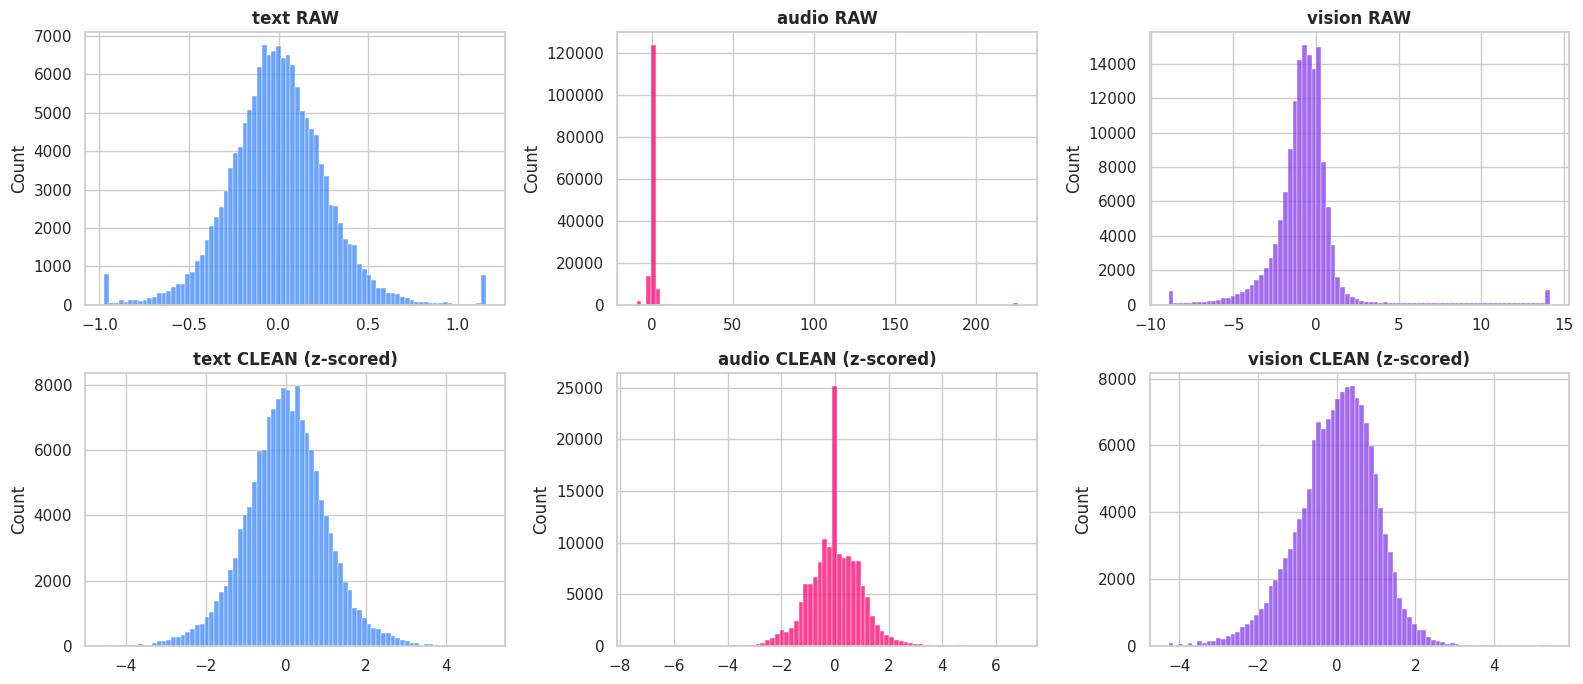

Saved /content/drive/MyDrive/IEMOCAP/processed/iemocap_clean.pkl (950.4 MB)
{
  "class_names": [
    "Neutral",
    "Happy",
    "Sad",
    "Angry"
  ],
  "n_classes": 4,
  "dims": {
    "text": 300,
    "audio": 74,
    "vision": 35
  },
  "seq_len": {
    "text": 20,
    "audio": 400,
    "vision": 500
  },
  "n": {
    "train": 2717,
    "valid": 798,
    "test": 938
  }
}


In [39]:
WINSOR = (0.5, 99.5)
CLEAN = {s: {k: v for k, v in DATA[s].items() if k in ('id', 'y', 'Y', 'labels_raw')} for s in SPLITS}
STATS = {}
for m in MODS:
    tr = np.nan_to_num(DATA['train'][m], nan=0.0, posinf=0.0, neginf=0.0)
    flat = tr[pad_mask(tr)]
    lo, hi = np.percentile(flat, WINSOR[0], axis=0), np.percentile(flat, WINSOR[1], axis=0)
    flat_w = np.clip(flat, lo, hi); mu, sd = flat_w.mean(0), flat_w.std(0) + 1e-6
    STATS[m] = {'lo': lo, 'hi': hi, 'mean': mu, 'std': sd}
    for s in SPLITS:
        X = np.nan_to_num(DATA[s][m], nan=0.0, posinf=0.0, neginf=0.0); mk = pad_mask(X)[..., None]
        Xn = (np.clip(X, lo, hi) - mu) / sd
        CLEAN[s][m] = (Xn * mk).astype(np.float32)          # padding stays exactly 0
        CLEAN[s][m + '_mask'] = mk[..., 0]
    f = CLEAN['train'][m][CLEAN['train'][m + '_mask']]
    print(f"{m:6}: after norm train mean={f.mean():+.4f}, std={f.std():.4f}, |max|={np.abs(f).max():.2f}")

# before/after visual
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for j, m in enumerate(MODS):
    b = sample_vals(DATA['train'][m]); a = CLEAN['train'][m][CLEAN['train'][m + '_mask']].ravel(); a = rng.choice(a, size=min(150000, len(a)), replace=False)
    sns.histplot(np.clip(b, *np.percentile(b, [0.5, 99.5])), bins=80, color=MOD_COLORS[m], ax=axes[0, j]); axes[0, j].set_title(f'{m} RAW', fontweight='bold')
    sns.histplot(a, bins=80, color=MOD_COLORS[m], ax=axes[1, j]); axes[1, j].set_title(f'{m} CLEAN (z-scored)', fontweight='bold')
plt.tight_layout(); plt.show()

# save
out_pkl = f'{OUT_DIR}/iemocap_clean.pkl'
with open(out_pkl, 'wb') as f: pickle.dump({'data': CLEAN, 'stats': STATS, 'class_names': CLASS_NAMES, 'class_weights': CLASS_WEIGHTS, 'winsor': WINSOR}, f, protocol=4)
json.dump({'class_names': CLASS_NAMES, 'n_classes': n_cls, 'dims': {m: int(CLEAN['train'][m].shape[-1]) for m in MODS},
           'seq_len': {m: int(CLEAN['train'][m].shape[1]) for m in MODS}, 'n': {s: int(len(CLEAN[s]['y'])) for s in SPLITS}}, open(f'{OUT_DIR}/meta.json', 'w'), indent=2)
print('Saved', out_pkl, f'({os.path.getsize(out_pkl) / 1e6:.1f} MB)'); print(open(f'{OUT_DIR}/meta.json').read())

## 6. PyTorch Dataset + missing-modality simulator

In [40]:
import torch
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('device:', device)

# Availability patterns (1 = available). Mirrors the 7 modality-availability cases used in missing-modality papers.
PATTERNS = {'T+A+V': (1, 1, 1), 'A+V (T missing)': (0, 1, 1), 'T+V (A missing)': (1, 0, 1), 'T+A (V missing)': (1, 1, 0),
            'T only': (1, 0, 0), 'A only': (0, 1, 0), 'V only': (0, 0, 1)}

def random_missing_mask(B, rate, gen=None):
    # each modality dropped w.p. `rate`; guarantee at least one modality survives. returns (B,3) {1=available}
    keep = (torch.rand(B, 3, generator=gen) >= rate).float()
    none = keep.sum(1) == 0
    if none.any(): keep[none, torch.randint(0, 3, (int(none.sum()),), generator=gen)] = 1.0
    return keep

class IEMOCAPDataset(Dataset):
    def __init__(self, split_dict):
        self.t, self.a, self.v = [torch.from_numpy(split_dict[m]) for m in MODS]
        self.y = torch.from_numpy(split_dict['y']).long()
        self.Y = torch.from_numpy(split_dict['Y']).float() if split_dict['Y'] is not None else None
        self.nat = torch.tensor(np.stack([~split_dict[m + '_mask'].any(1) for m in MODS], 1)).float()   # 1 => naturally empty
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {'text': self.t[i], 'audio': self.a[i], 'vision': self.v[i], 'label': self.y[i], 'natural_missing': self.nat[i],
                **({'multilabel': self.Y[i]} if self.Y is not None else {})}

def apply_missing(batch, avail):
    # avail: (B,3) float tensor [T,A,V] {1=available}. Zero-fills the dropped modality (baseline strategy; MMGM will replace this).
    out = dict(batch); out['avail'] = avail
    for j, m in enumerate(MODS): out[m + '_in'] = batch[m] * avail[:, j].view(-1, 1, 1)
    return out

BATCH = 32
loaders = {s: DataLoader(IEMOCAPDataset(CLEAN[s]), batch_size=BATCH, shuffle=(s == 'train'), drop_last=False) for s in SPLITS}
b = next(iter(loaders['train']))
print({k: tuple(v.shape) for k, v in b.items()})

# sanity check of the simulator
g = torch.Generator().manual_seed(SEED)
for r in [0.0, 0.3, 0.5, 0.7]:
    mk = random_missing_mask(10000, r, g); print(f"rate={r:.1f} -> empirical drop per modality (T,A,V) = {(1 - mk.mean(0)).numpy().round(3)} | all-3-present = {(mk.sum(1) == 3).float().mean():.3f}")
mb = apply_missing(b, torch.tensor(PATTERNS['T+V (A missing)'], dtype=torch.float32).expand(len(b['label']), 3))
print('audio energy after dropping A:', mb['audio_in'].abs().sum().item(), '| text energy kept:', mb['text_in'].abs().sum().item() > 0)

device: cpu
{'text': (32, 20, 300), 'audio': (32, 400, 74), 'vision': (32, 500, 35), 'label': (32,), 'natural_missing': (32, 3), 'multilabel': (32, 4)}
rate=0.0 -> empirical drop per modality (T,A,V) = [0. 0. 0.] | all-3-present = 1.000
rate=0.3 -> empirical drop per modality (T,A,V) = [0.291 0.286 0.293] | all-3-present = 0.345
rate=0.5 -> empirical drop per modality (T,A,V) = [0.453 0.454 0.458] | all-3-present = 0.126
rate=0.7 -> empirical drop per modality (T,A,V) = [0.583 0.583 0.589] | all-3-present = 0.026
audio energy after dropping A: 0.0 | text energy kept: True


## 7. Summary of what we learned
Run the cells above, then look at: label imbalance & class weights (2.1), natural zero samples (2.2), dead dimensions & scale disparity (2.2–2.3), which modality is strongest (3.1), how reconstructable each modality is (3.2), and whether retrieval / residual-retrieval gains exist (3.3).
**Next stage:** MulT/MPLMM baseline training on `iemocap_clean.pkl` using the loaders above.